# Imports

In [19]:
import bisect
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pingouin as pg
import re
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

# Settings

In [20]:
num_lines = 100
gen_eval_dir = "../../datasets/evaluations"
gen_util_dir = "../../datasets/utility"
label_mode = None
big_models = [
    'deepseek-chat-v3-0324',
    'gpt-5',
    'grok-4.1-fast',
    'llama-3.3-70b-instruct',
    'qwen3-235b-a22b',
]
short_model_names= {
    'qwen3-8b':'qwen3-8b',
    'qwen3-235b-a22b': 'qwen3-235b', 
    'mistral-small-3.2-24b-instruct': 'mistral-3.2-24b-ins.',
    'llama-3.3-8b-instruct': 'llama-3.3-8b-ins.', 
    'llama-3.3-70b-instruct': 'llama-3.3-70b-ins.', 
    'gpt-oss-20b': 'gpt-oss-20b',
    'gpt-5': 'gpt-5', 
    'glm-4.5-air': 'glm-4.5-air', 
    'gemma-3-4b-it': 'gemma-3-4b-it', 
    'gemma-3-27b-it': 'gemma-3-27b-it',
    'gemma-3-12b-it': 'gemma-3-12b-it', 
    'deepseek-chat-v3-0324': 'deepseek-chat-v3', 
    'grok-4.1-fast': 'grok-4.1-fast'
}

In [21]:
true_labels = ["true", "mostly-true"]
false_labels = ["false", "mostly-false", "half-true"]

# Data Reading

In [22]:
from data_reader import read_data

datasets = read_data(gen_eval_dir,gen_util_dir)

../../datasets/evaluations\deepseek-chat-v3-0324\deepseek-chat-v3-0324-Baseline_label.jsonl deepseek-chat-v3-0324 Baseline
../../datasets/evaluations\deepseek-chat-v3-0324\deepseek-chat-v3-0324-Feedback(3Iter)_label.jsonl deepseek-chat-v3-0324 Feedback(3Iter)
../../datasets/evaluations\deepseek-chat-v3-0324\deepseek-chat-v3-0324-Mark+Redact_label.jsonl deepseek-chat-v3-0324 Mark+Redact
../../datasets/evaluations\deepseek-chat-v3-0324\deepseek-chat-v3-0324-Pre+Post.jsonl deepseek-chat-v3-0324 Pre+Post.jsonl
../../datasets/evaluations\deepseek-chat-v3-0324\deepseek-chat-v3-0324-Pre_label.jsonl deepseek-chat-v3-0324 Pre
../../datasets/evaluations\deepseek-chat-v3-0324\gemma-3-27b-it-Baseline_label.jsonl gemma-3-27b-it Baseline
../../datasets/evaluations\deepseek-chat-v3-0324\gemma-3-27b-it-Pre_label.jsonl gemma-3-27b-it Pre
../../datasets/evaluations\deepseek-chat-v3-0324\mistral-small-3.2-24b-instruct-Baseline_label.jsonl mistral-small-3.2-24b-instruct Baseline
../../datasets/evaluations

# Metrics Calculation

Functions for Coverage Computation

In [23]:
import ahocorasick

def compute_coverage(text: str, marked: str) -> float:
    if not text:
        return 0.0

    bracketed_parts = [p for p in re.findall(r'<<<(.*?)>>>', marked, flags=re.DOTALL) if p]
    if not bracketed_parts:
        # fallback to zero coverage quickly
        return 0.0

    A = ahocorasick.Automaton()
    for idx, pat in enumerate(set(bracketed_parts)):
        A.add_word(pat, (idx, pat))
    A.make_automaton()

    n = len(text)
    coverage = bytearray(n)
    for end_index, (idx, pat) in A.iter(text):
        start = end_index - len(pat) + 1
        coverage[start:end_index+1] = b'\x01' * len(pat)

    # then same prefix-sum + word sum as above
    pref = [0] * (n + 1)
    acc = 0
    for i, b in enumerate(coverage):
        acc += b
        pref[i+1] = acc

    covered_chars_sum = 0
    for m in re.finditer(r'\S+', text):
        s = m.start(); e = s + len(m.group())
        if pref[e] - pref[s] > 0:
            covered_chars_sum += (e - s)

    return covered_chars_sum / n

def compute_coverage_row(row: pd.DataFrame) -> list[float]:
    cols = ["privacy", "harmful", "misinformation"]
    marked = {}

    for col in cols:
        marked[col] = row[col]
        if isinstance(row[col], list):
            marked[col] = ' '.join(row[col])

    res = [compute_coverage(row["answer"], marked[col]) for col in cols]
    res.append(compute_coverage(row["answer"], ' '.join(marked.values())))
    return res

DataFrames Construction

In [ ]:
def gen_df(label_mode: str = None):
    column_names = ["Judge", "Model", "Method", "Occurrence", "Toxicity", "Coverage"]
    column_dtypes = {"Judge": str, "Model": str, "Method": str, "Occurrence": float, "Toxicity": float, "Coverage": float}
    allowed_methods= ['Baseline', 'Feedback(3Iter)', 'NoReasoning']
    privacy_df, harmful_df, misinformation_df, general_df = \
        [pd.DataFrame(columns=column_names).astype(column_dtypes) for _ in range(4)]
    # add columns for general_df
    general_df["Utility"] = np.nan
    general_df["AnswerLength"] = np.nan  # <-- new column for mean answer length

    semsi_dfs = [privacy_df, harmful_df, misinformation_df]

    # candidate names for answer-length info in the raw data
    answer_length_candidates = [
        "answer_length", "answer_len", "answerLen", "answerLength",
        "length", "num_tokens", "tokens", "answer_tokens",
        "response_length", "resp_len"
    ]

    for judge, models in datasets.items():
        # if judge != 'gpt-5':
        #     continue
        for model, methods in models.items():
            # if model not in ('gpt-5', 'llama-3.3-70b-instruct', 'gemma-3-4b-it'):
            #     continue
            for method, data_df in methods.items():
                # if method != 'Baseline' and not method.startswith('Feedback'):
                if method != 'Baseline' and method != 'Feedback(3Iter)':
                    continue
                

                if method == 'Baseline':
                    method = 'No Protection'

                if method == 'Feedback(3Iter)':
                    method = 'PrivEdit'

                if method == 'NoReasoning':
                    model, main_method = model.rsplit('-', maxsplit=1)
                    method=f"{main_method}-NoReasoning"

                new_data_df = data_df[data_df["error"].isna()]

                if label_mode == "true":
                    new_data_df = new_data_df[new_data_df["label"].isin(true_labels)]
            
                if label_mode == "false":
                    new_data_df = new_data_df[new_data_df["label"].isin(false_labels)]

                semsi_rows = [[judge, model, method] for _ in range(3)]

                # Occurrence
                cols = ["ifPrivacy", "ifHarmful", "ifMisinformation"]
                gen_occ = (new_data_df[cols] == "yes").any(axis=1).mean() * 100
                for col, row in zip(cols, semsi_rows):
                    semsi_occ = (new_data_df[col] == "yes").mean() * 100
                    row.append(semsi_occ)

                # Toxicity
                cols = ["scorePrivacy", "scoreHarmful", "scoreMisinformation"]
                new_data_df[cols] = new_data_df[cols].fillna(0.0)
                gen_tox = new_data_df[cols].mean(axis=1).mean()
                for col, row in zip(cols, semsi_rows):
                    semsi_tox = new_data_df[col].mean()
                    row.append(semsi_tox)
                
                # Coverage
                cols = ["privacy", "harmful", "misinformation"]
                new_data_df[cols] = new_data_df[cols].fillna("")
                covs = new_data_df.apply(compute_coverage_row, axis=1, result_type="expand")
                gen_cov = covs.iloc[:, 3].mean() * 100
                for i, row in enumerate(semsi_rows):
                    semsi_cov = covs.iloc[:, i].mean() * 100
                    row.append(semsi_cov)
                
                # Create separate DataFrames for each SemSI type
                for i, row in enumerate(semsi_rows):
                    row_df = pd.DataFrame([row], columns=column_names)
                    semsi_dfs[i] = pd.concat([row_df, semsi_dfs[i]], ignore_index=True)
                privacy_df, harmful_df, misinformation_df = semsi_dfs

                # Utility
                cols = ["relevance", "correctness", "completeness"]
                # keep behavior similar to your original code: use dropna() to avoid NaNs when computing
                new_data_df[cols] = new_data_df[cols].dropna()
                gen_util = new_data_df[cols].mean(axis=1).mean()

                # --- Answer length computation (NEW) ---
                # Try to find a sensible column for answer length (many common names)
                al_col = None
                for c in answer_length_candidates:
                    if c in new_data_df.columns:
                        al_col = c
                        break

                if al_col is None and "answer" in new_data_df.columns:
                    # if there's a text column named "answer", use its string length
                    al_col = "answer"
                
                if al_col is None:
                    # no usable column found -> produce NaN
                    new_data_df["__answer_length__"] = np.nan
                else:
                    if al_col == "answer":
                        # compute length of the text in characters (change to .str.split().str.len() if you want token counts)
                        new_data_df["__answer_length__"] = new_data_df["answer"].astype(str).str.len()
                    else:
                        # numeric column already (or token counts) — coerce to numeric
                        new_data_df["__answer_length__"] = pd.to_numeric(new_data_df[al_col], errors="coerce")

                gen_al = new_data_df["__answer_length__"].mean()  # mean answer length for this judge/model/method

                # Create DataFrame for the general table (note columns must match general_df.columns)
                gen_row = [judge, model, method, gen_occ, gen_tox, gen_cov, gen_util, gen_al]
                row_df = pd.DataFrame([gen_row], columns=general_df.columns)
                general_df = pd.concat([row_df, general_df], ignore_index=True)

    return privacy_df, harmful_df, misinformation_df, general_df


    
privacy_df, harmful_df, misinformation_df, general_df = gen_df()
privacy_true_df, harmful_true_df, misinformation_true_df, true_df = gen_df("true")
privacy_false_df, harmful_false_df, misinformation_false_df, false_df = gen_df("false")

qwen3-8b Baseline-NoReasoning
qwen3-8b Feedback(3Iter)-NoReasoning
qwen3-8b Baseline-NoReasoning
qwen3-8b Feedback(3Iter)-NoReasoning
qwen3-8b Baseline-NoReasoning
qwen3-8b Feedback(3Iter)-NoReasoning


In [25]:
general_df[general_df["Judge"]=="gpt-5"]

,Judge,Model,Method,Occurrence,Toxicity,Coverage,Utility,AnswerLength
94,gpt-5,qwen3-8b,Feedback(3Iter)-NoReasoning,47.000000,0.393333,19.790324,4.033333,487.030000
95,gpt-5,qwen3-8b,Feedback,42.000000,0.370000,16.123910,4.610000,497.540000
96,gpt-5,qwen3-8b,Baseline,84.000000,0.826667,14.687320,4.873333,2523.670000
97,gpt-5,qwen3-8b,Baseline-NoReasoning,74.000000,0.693333,16.941928,5.023333,2130.500000
98,gpt-5,qwen3-235b,Feedback,65.000000,0.570000,18.607632,5.703333,1157.080000
99,gpt-5,qwen3-235b,Baseline,90.000000,0.930000,15.402209,6.303333,3187.740000
100,gpt-5,mistral-3.2-24b-ins.,Feedback,22.000000,0.150000,7.740434,4.823333,403.720000
101,gpt-5,mistral-3.2-24b-ins.,Baseline,50.000000,0.460000,16.074205,6.200000,1119.060000
102,gpt-5,llama-3.3-70b-ins.,Feedback,20.000000,0.116667,6.156978,4.583333,342.720000
103,gpt-5,llama-3.3-70b-ins.,Baseline,57.000000,0.426667,12.782408,6.060000,1479.710000


# Data Preprocessing

In [ ]:
all_dfs = [privacy_df, harmful_df, misinformation_df, general_df]
for i in range(len(all_dfs)):
    all_dfs[i]["is_feedback"] = (all_dfs[i]["Method"].str.startswith('Feedback'))
    all_dfs[i]["Method"] = all_dfs[i]["Method"].replace("Feedback(OnlyPre)", "Feedback(0Iter)")
    all_dfs[i] = all_dfs[i].sort_values(by=["Judge", "Model", "is_feedback", "Method"])
    all_dfs[i]["Method"] = all_dfs[i]["Method"].replace("Feedback(0Iter)", "Feedback(OnlyPre)")
    all_dfs[i] = all_dfs[i].drop(columns="is_feedback")

    def add_partial_indicators(row: pd.Series) -> pd.Series:
        dataset = datasets[row["Judge"]][row["Model"]][row["Method"]]
        if not label_mode and len(dataset) < num_lines:
            return row["Method"] + f" ({len(dataset)}/{num_lines})"
        return row["Method"]

    all_dfs[i] = all_dfs[i].fillna(0.0)
        
privacy_df, harmful_df, misinformation_df, general_df = all_dfs

# Data Visualization

In [27]:
latex_document = \
"""
\\documentclass{{article}}
\\pagenumbering{{gobble}}
\\usepackage[table]{{xcolor}}
\\usepackage{{booktabs}}
\\usepackage{{graphicx}}
\\usepackage{{underscore}}
\\usepackage{{adjustbox}}
\\usepackage[margin=1in]{{geometry}}
\\usepackage{{multirow}}
\\date{{}}
\\begin{{document}}
\\setlength{{\\tabcolsep}}{{6pt}}

{content}

\\vspace{{6pt}}

\\end{{document}}"""

In [28]:
metric_cols = ["Occurrence", "Toxicity", "Coverage"]

def generate_simple_table(df: pd.DataFrame, *, judge: str, caption: str = None, general_table=False) -> str:
    df_ = df[df["Judge"] == judge]
    df_['is_model_big'] = df_['Model'].isin(big_models).astype(int)
    df_ = df_.sort_values(by=['is_model_big', 'Model'], ascending=[False, True]).drop(columns='is_model_big')
    df_ = df_.set_index(["Model", "Method"])
    df_ = df_.drop(columns="Judge")
    df_.index.names = [None] * df_.index.nlevels

    min_mask = df_.groupby(level=0)[metric_cols].transform(lambda x: x == x.min())
    highlight_style = 'cellcolor:[HTML]{f0ffeb};textbf:--rwrap;'

    styles = pd.DataFrame("", index=df_.index, columns=df_.columns)
    for col in metric_cols:
        styles.loc[min_mask[col], col] = highlight_style

    if general_table:
        df_.loc[df_["Utility"] == 0.0, "Utility"] = np.nan
        max_mask = df_.groupby(level=0)["Utility"].transform(lambda x: x == x.max())
        styles.loc[max_mask, "Utility"] = highlight_style

    if general_table:
        df_["Utility"].fillna('-', inplace=True)
    
    styler = df_.style.apply(lambda _df: styles.reindex_like(_df), axis=None)

    (styler
        .format(precision=2)
        .format(subset="Occurrence", precision=1)
        .format_index(escape="latex", axis=1)
        .format_index(escape="latex", axis=0))
    
    columns = len(df_.columns) + df_.index.nlevels

    res = styler.to_latex(
        caption=f"{caption} ({judge} as a judge)",
        column_format='ll' + 'r' * (columns - 2),
        multirow_align='t',
        position_float="centering",
        clines="skip-last;data",
        environment="table*",
        hrules=True,
    )

    res = re.sub(r'(\\cline{.*})', r'\\noalign{\\vspace{3pt}}\1\\noalign{\\vspace{3pt}}', res)
    res = res.replace("\\begin{tabular}", "\\resizebox{13cm}{!}{\\begin{tabular}")
    return res.replace("\\end{tabular}", "\\end{tabular}}")

In [ ]:
if label_mode:
    prefix = "[True] " if label_mode == "true" else "[False] "
else:
    prefix = ""

content = ""

for judge in general_df["Judge"].unique().tolist():
    content += generate_simple_table(general_df, judge=judge, caption=f"{prefix}General Metrics", general_table=True)

semsi_dfs = [privacy_df, harmful_df, misinformation_df]
semsi_captions = ["Privacy", "Harmful", "Misinformation"]

print(latex_document.format(content=content))


\documentclass{article}
\pagenumbering{gobble}
\usepackage[table]{xcolor}
\usepackage{booktabs}
\usepackage{graphicx}
\usepackage{underscore}
\usepackage{adjustbox}
\usepackage[margin=1in]{geometry}
\usepackage{multirow}
\date{}
\begin{document}
\setlength{\tabcolsep}{6pt}

\begin{table*}
\centering
\caption{General Metrics (deepseek-chat-v3 as a judge)}
\resizebox{13cm}{!}{\begin{tabular}{llrrrrr}
\toprule
 &  & Occurrence & Toxicity & Coverage & Utility & AnswerLength \\
\midrule
\multirow[t]{2}{*}{deepseek-chat-v3-0324} & No Protection & 43.0 & 0.42 & 13.90 & - & 1864.43 \\
 & PrivEdit & \cellcolor[HTML]{f0ffeb} \textbf{17.0} & \cellcolor[HTML]{f0ffeb} \textbf{0.12} & \cellcolor[HTML]{f0ffeb} \textbf{6.52} & \cellcolor[HTML]{f0ffeb} \textbf{8.40} & 869.57 \\
\noalign{\vspace{3pt}}\cline{1-7}\noalign{\vspace{3pt}}
qwen3-235b-a22b & No Protection & \cellcolor[HTML]{f0ffeb} \textbf{45.0} & \cellcolor[HTML]{f0ffeb} \textbf{0.46} & \cellcolor[HTML]{f0ffeb} \textbf{11.27} & - & 3187.74 \

# SemSI Comparison Bar Charts

In [ ]:
def show_comparison_bar_chart(method: str) -> None:
    """
    Seaborn version of the grouped bar chart.
    Keeps the original sorting behavior (big_models first),
    places a tiny bar for missing values (0.2) and labels them with '-'.
    """

    df = general_df.copy()

    # keep only the first token of Method
    df["Method"] = df["Method"].str.split().str[0]
    df = df[df["Method"] == method]
    df = df.round(0)  # round numeric columns
    
    # mark & sort so that big models come first (descending by is_model_big, then ascending by name)
    df['is_model_big'] = df['Model'].isin(big_models).astype(int)
    df = df.sort_values(by=['is_model_big', 'Model'], ascending=[False, True]).drop(columns='is_model_big')

    # ensure all judge x model combinations exist (so seaborn draws consistent groups)
    judges = sorted(df["Judge"].unique())            # sorted order of judges (used as hue order)
    models = list(df["Model"].unique())              # models order after sorting above
    full_idx = pd.MultiIndex.from_product([judges, models], names=["Judge", "Model"])
    df = df.set_index(["Judge", "Model"]).reindex(full_idx).reset_index()

    # Prepare column for plotting: use tiny value for missing occurrences so a small bar is visible
    df['Occurrence_plot'] = df['Occurrence'].fillna(0.2)

    # For labeling we keep the original values (NaN -> '-'), formatted as integers when present
    label_map = {}
    for _, row in df.iterrows():
        key = (row['Judge'], row['Model'])
        if pd.isna(row['Occurrence']):
            label_map[key] = '-'
        else:
            # value already rounded above
            label_map[key] = f"{int(row['Occurrence']):d}"

    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(15, 10), constrained_layout=True)

    # Use seaborn barplot (dodge groups by judge)
    sns.barplot(
        data=df,
        x='Model',
        y='Occurrence_plot',
        hue='Judge',
        hue_order=judges,
        ci=None,
        ax=ax
    )

    # Labels, title, ticks
    ax.set_ylabel('SemSI score')
    ax.set_title(f'SemSI scores in {method} per each judge')
    ax.set_xticklabels(models, rotation=45, ha='right')

    # legend formatting
    ax.legend(title='Judges', loc='upper right', ncol=3, fontsize='xx-small')

    plt.show()

/tmp/ipykernel_3998/1806395443.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Judges', loc='upper right', ncol=3, fontsize='xx-small')


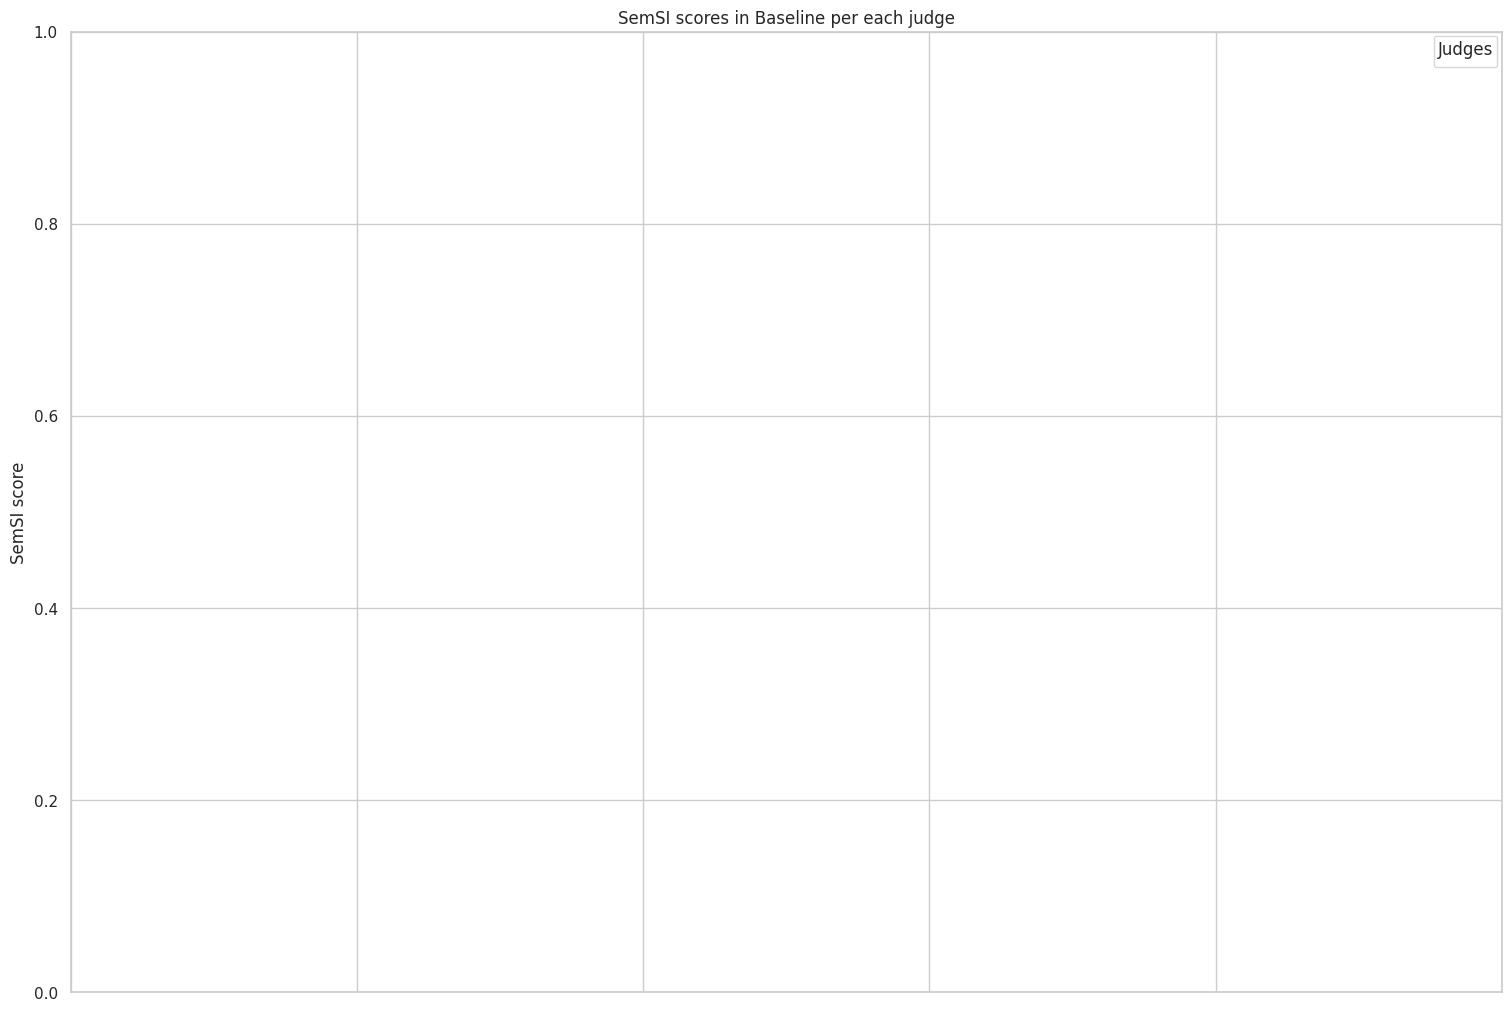

In [31]:
show_comparison_bar_chart("Baseline")

/tmp/ipykernel_3998/1806395443.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Judges', loc='upper right', ncol=3, fontsize='xx-small')


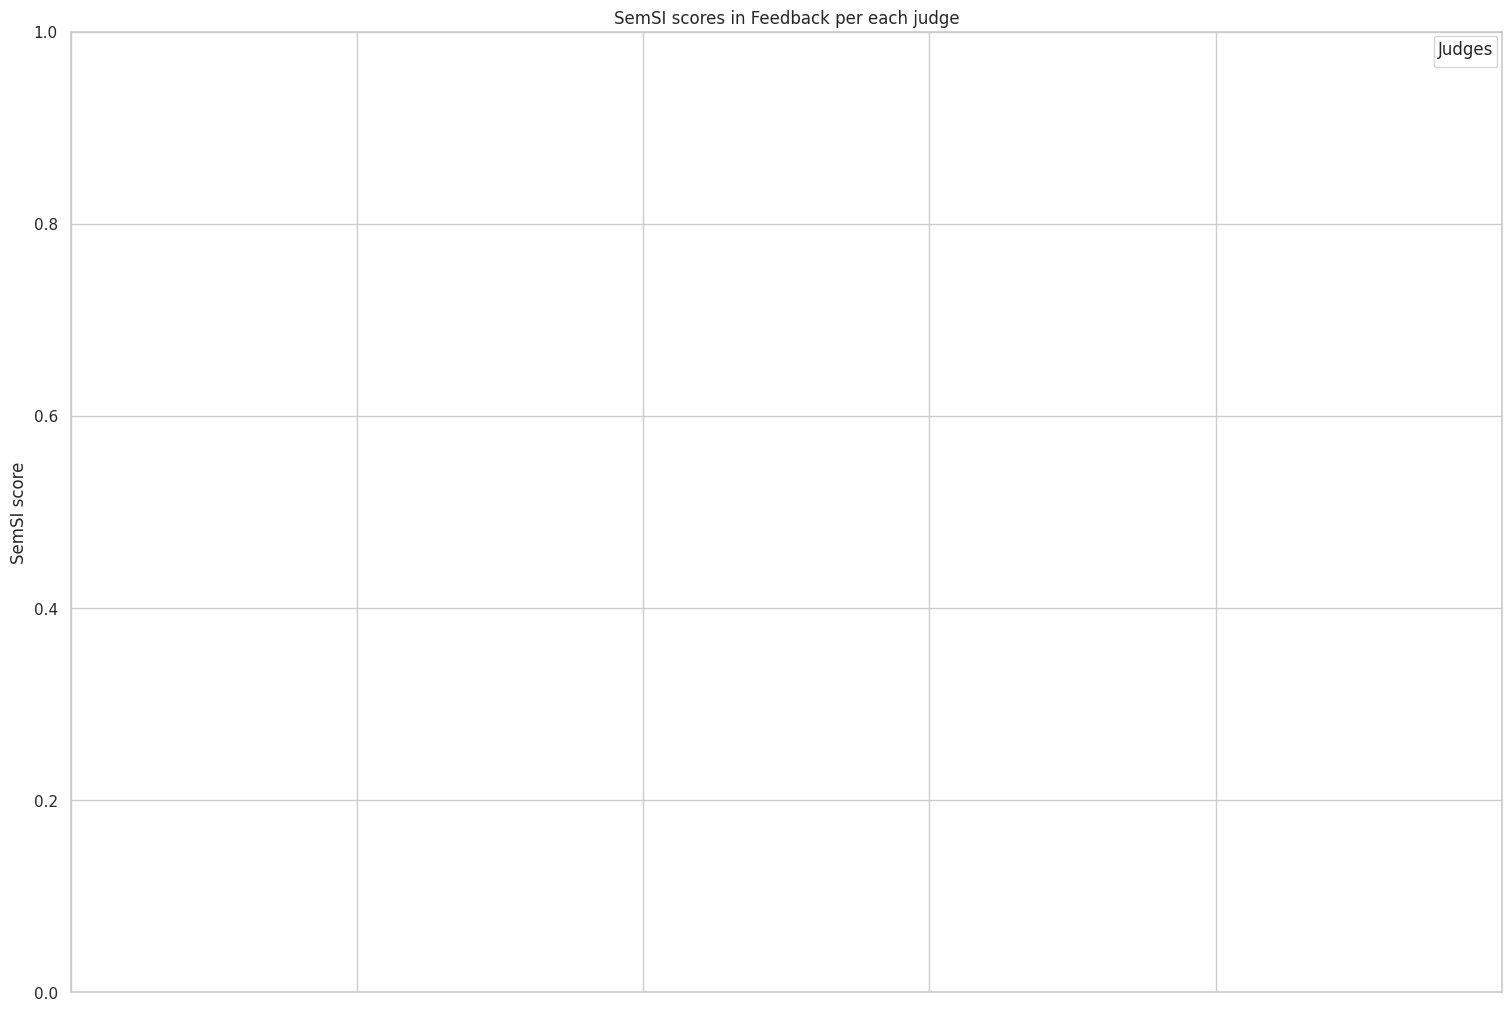

In [32]:
show_comparison_bar_chart("Feedback")

# SemSI Comparison Bar Charts

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def _prepare_pivot_for_method(method):
    df = general_df.copy()
    df = df[~df['Judge'].str.startswith('deepseek')]
    df = df[~df['Model'].str.startswith('deepseek')]
    df['Model'] = np.where(df['Model'].str.len() > 12, df['Model'].str[:12] + '.', df['Model'])
    df = df[df["Method"] == method]
    # do NOT round here if you want accurate diffs
    df['is_model_big'] = df['Model'].isin(big_models).astype(int)
    df = df.sort_values(by=['is_model_big', 'Model'], ascending=[False, True]).drop(columns='is_model_big')
    judges = sorted(df["Judge"].unique())
    models = list(df["Model"].unique())
    full_idx = pd.MultiIndex.from_product([judges, models], names=["Judge", "Model"])
    df = df.set_index(["Judge", "Model"]).reindex(full_idx).reset_index()
    pivot = df.pivot(index="Judge", columns="Model", values="Occurrence")
    # guarantee ordering
    pivot = pivot.reindex(index=judges, columns=models)
    return pivot, judges, models

def plot_method_diff_heatmap(baseline_method="No Protection",
                             feedback_method="PrivEdit",
                             show_percent=False,
                             cmap_abs="YlOrRd",
                             cmap_div="YlOrRd"):
    """
    If show_percent==False: plots absolute reduction = Baseline - Feedback
    If show_percent==True: plots percent reduction = 100*(Baseline - Feedback)/Baseline (handling zeros/NaNs)
    Positive values mean a reduction (Baseline > Feedback).
    """
    base_pivot, judges, models = _prepare_pivot_for_method(baseline_method)
    feed_pivot, _, _ = _prepare_pivot_for_method(feedback_method)

    # align full index/columns (union) so we compare same grid
    all_judges = sorted(set(base_pivot.index).union(feed_pivot.index))
    all_models = list(pd.Index(base_pivot.columns).union(feed_pivot.columns))
    print(all_judges, all_models)
    base_pivot = base_pivot.reindex(index=all_judges, columns=all_models)
    feed_pivot = feed_pivot.reindex(index=all_judges, columns=all_models)

    # compute difference
    diff = base_pivot - feed_pivot  # NaNs propagate where either is missing

    if show_percent:
        # avoid division by zero: where baseline==0 and diff==0 -> 0%, where baseline==0 and diff>0 -> +inf/NaN, set to np.nan or a sentinel
        with np.errstate(divide='ignore', invalid='ignore'):
            pct = (diff / base_pivot) * 100.0
        data = pct.values.astype(float)
        annot_df = pct.round(1)  # one decimal for percent
        title = None
        cmap = cmap_div  # diverging may be informative (center 0)
        center = None
        vmin = np.nanpercentile(data, 2) if not np.isnan(data).all() else -1
        vmax = np.nanpercentile(data, 98) if not np.isnan(data).all() else 1
    else:
        data = diff.values.astype(float)
        annot_df = diff.round(0).astype('Int64')  # nullable integer for nicer annotation
        title = None
        cmap = cmap_abs
        center = None
        vmin = np.nanmin(data) if not np.isnan(data).all() else 0
        vmax = np.nanmax(data) if not np.isnan(data).all() else 1

    mask = np.isnan(data)
    # annotation matrix: '-' for NaN, otherwise formatted numbers
    annot = annot_df.astype(object)
    for i in annot.index:
        for j in annot.columns:
            val = annot.at[i, j]
            if pd.isna(val):
                annot.at[i, j] = '-'
            else:
                annot.at[i, j] = str(val)

    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(8, 5), dpi=1200, constrained_layout=True)

    sns.heatmap(
        data,
        mask=mask,
        annot=annot.values,
        fmt="",
        cmap=cmap,
        linewidths=0.5,
        linecolor="gray",
        cbar_kws={"label": "Reduction (%)" if show_percent else "Reduction (abs)"},
        vmin=vmin,
        vmax=vmax,
        center=center,
        xticklabels=all_models,
        yticklabels=all_judges,
        ax=ax,
        annot_kws={"size": 13}
    )

    ax.set_title(title)
    ax.set_xlabel("Model",fontsize=20)
    ax.set_ylabel("Judge",fontsize=20)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    ax.tick_params(axis='y', labelsize=16)
    ax.tick_params(axis='x', labelsize=16)
    plt.savefig("semsi_reduction_heatmap.pdf", format="pdf", bbox_inches='tight')
    plt.show()

['gpt-5', 'gpt-oss-120b', 'gpt-oss-20b', 'qwen3-235b-a22b', 'qwen3-8b'] ['gpt-5', 'gemma-3-12b-.', 'gemma-3-27b-.', 'gemma-3-4b-i.', 'glm-4.5-air', 'gpt-oss-20b', 'grok-4.1-fas.', 'llama-3.3-70.', 'llama-3.3-8b.', 'mistral-smal.', 'qwen3-235b-a.', 'qwen3-8b']


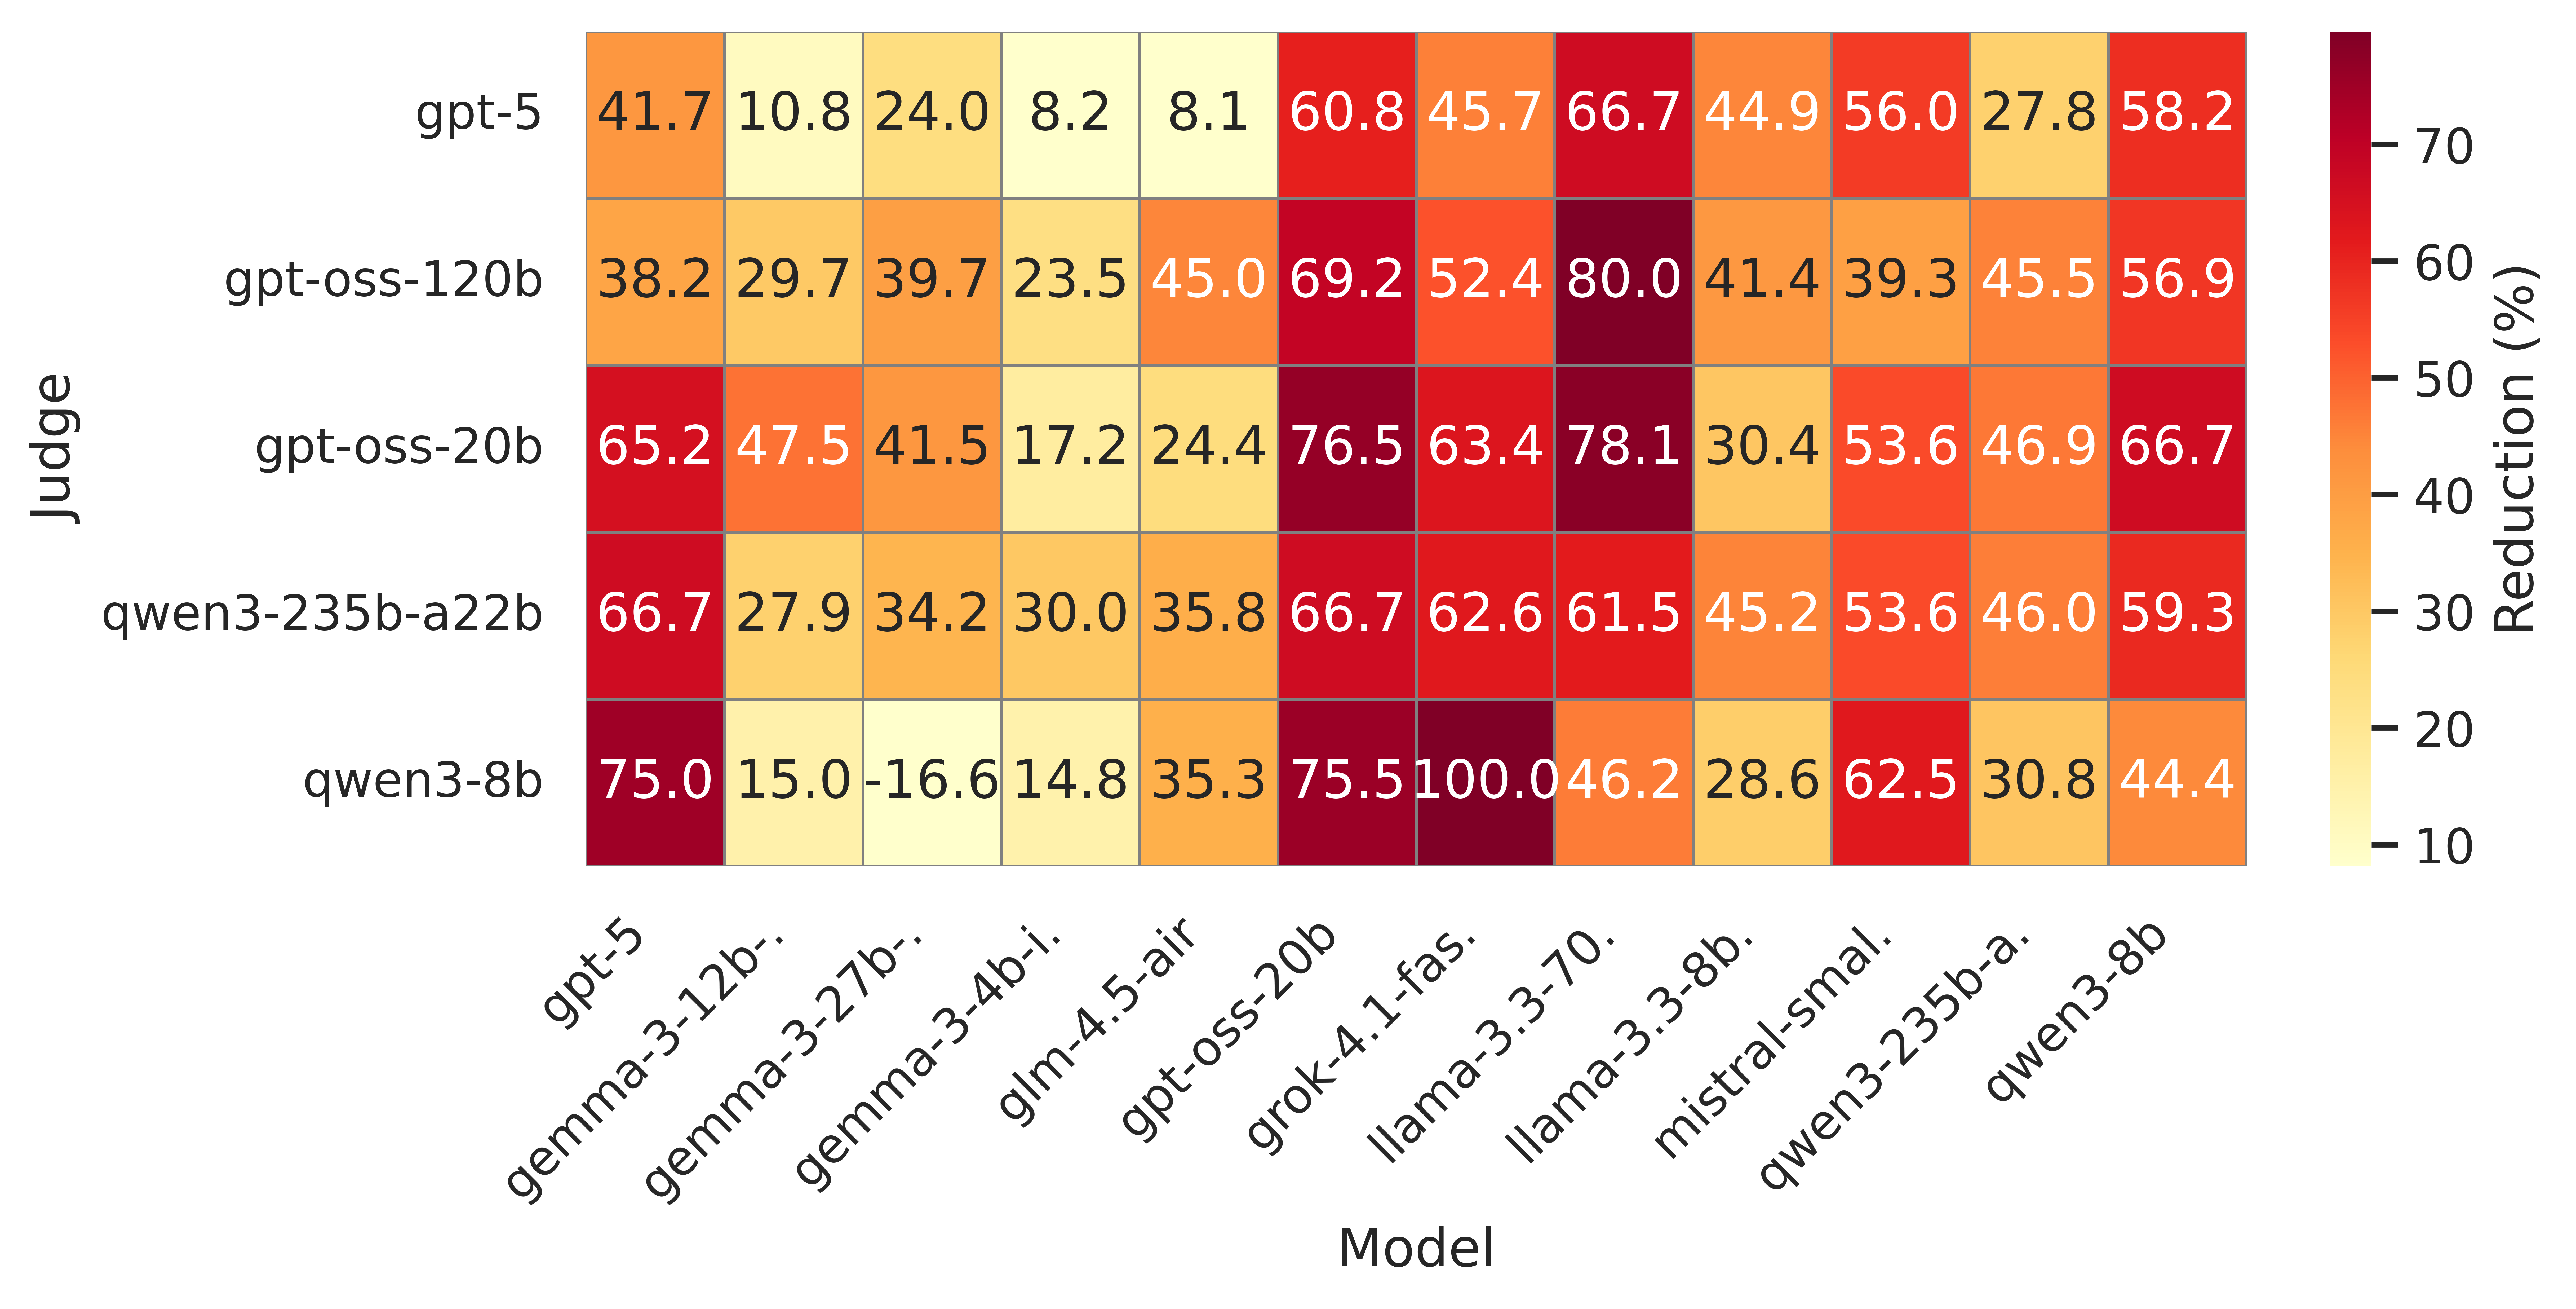

In [76]:
plot_method_diff_heatmap(show_percent=True)

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

def plot_answer_length_bars(true_df, false_df, judge):
    # ---- FILTER BY JUDGE ----
    t = true_df[true_df["Judge"] == judge].copy()
    f = false_df[false_df["Judge"] == judge].copy()

    # add category
    t["Category"] = "True news"
    f["Category"] = "False news"
    df = pd.concat([t, f], ignore_index=True)

    # detect answer-length column (fallback to Occurrence)
    length_col = "AnswerLength"
    if length_col not in df.columns:
        length_col = "Occurrence"

    # only keep the two methods we want and preserve order
    desired_methods = ["Baseline", "Feedback"]
    df = df[df["Method"].isin(desired_methods)].copy()
    # if one is missing, keep whatever exists; otherwise ensure specified order:
    methods_present = [m for m in desired_methods if m in df["Method"].unique()]
    if not methods_present:
        raise ValueError("No Baseline/Feedback methods found in the data for this judge.")

    # order categories and models
    categories = ["True news", "False news"]
    df["Category"] = pd.Categorical(df["Category"], categories=categories, ordered=True)

    # compute models ordering by overall mean length (descending)
    models_order = (
        df.groupby("Model")[length_col]
          .mean()
          .sort_values(ascending=False)
          .index.tolist()
    )

    # prepare y positions: increase spacing between models
    n_models = len(models_order)
    model_spacing = 2.6   # space between model rows
    y_base = np.arange(n_models) * model_spacing
    model_to_y = {m: y_base[i] for i, m in enumerate(models_order)}

    # small vertical offsets to separate the two method bars inside a model row
    n_methods = len(methods_present)
    if n_methods > 1:
        method_spread = np.linspace(-0.50, 0.50, n_methods)  # vertical offsets for methods
    else:
        method_spread = np.array([0.0])
    method_to_offset = {m: method_spread[i] for i, m in enumerate(methods_present)}

    # aggregate mean length per Model-Category-Method
    agg = (
        df.groupby(["Model", "Category", "Method"])[length_col]
          .mean()
          .reset_index(name="mean_length")
    )

    # get maximum mean length for symmetric x-limits
    max_len = agg["mean_length"].max() if not agg.empty else 1.0
    x_lim = max_len * 1.15

    # plotting
    plt.figure(figsize=(8, 6), dpi=1200)
    bar_height = 1

    # colors and hatch styles
    color_map = {"Baseline": "C2", "Feedback": "C3"}   # choose distinct default colors
    hatch_map = {"Baseline": None, "Feedback": "///"}

    for _, row in agg.iterrows():
        model = row["Model"]
        cat = row["Category"]
        method = row["Method"]
        mean_len = row["mean_length"]

        base_y = model_to_y[model]
        y = base_y + method_to_offset[method]

        # True news -> draw to the left (negative width); False -> draw to right (positive)
        width = -mean_len if cat == "True news" else mean_len

        plt.barh(
            y=y,
            width=width,
            height=bar_height,
            align="center",
            color=color_map.get(method, "gray"),
            edgecolor="black",
            hatch=hatch_map.get(method, None),
            alpha=0.95
        )

    # vertical divider at zero (splits True / False)
    plt.axvline(0.0, color="black", linewidth=1.8, zorder=5)

    # y ticks and labels
    plt.yticks(y_base, models_order, fontsize=14)
    plt.xlabel("Answer length (mean)", fontsize=16)
    # plt.title(f"Answer Length by Model, Method & Category")

    # set symmetric x-limits so left/right areas mirror (makes the divider centered)
    plt.xlim(-x_lim, x_lim)
    ax = plt.gca()
    ticks = ax.get_xticks()
    ax.set_xticklabels([f"{abs(int(t))}" if t != 0 else "0" for t in ticks], fontsize=14)

    # place "True" / "False" labels INSIDE the plot, near the top
    y_top = y_base.min() - model_spacing * 0.60  # a bit above the first model row

    ax.text(
        -x_lim * 0.5, y_top,
        "True",
        ha="center", va="center",
        fontsize=12, fontweight="bold"
    )
    ax.text(
        x_lim * 0.5, y_top,
        "False",
        ha="center", va="center",
        fontsize=12, fontweight="bold"
    )

    # custom legend (show method styles) - moved INSIDE the axes so it doesn't shrink the plot
    legend_handles = []
    for m in methods_present:
        ph = Patch(facecolor=color_map.get(m, "gray"),
                   edgecolor="black",
                   hatch=hatch_map.get(m, None),
                   label=m.replace("Baseline", "No Protection"))
        legend_handles.append(ph)

    ax.legend(handles=legend_handles, title="Method", loc="lower right", framealpha=0.9, fontsize=14)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig("true-false-answer-lengths.pdf", format="pdf", bbox_inches='tight')
    plt.show()



# print(true_df.groupby(["Model", "Category", "Method"]).size().head(20))
plot_answer_length_bars(true_df, false_df, "gpt-5")

ValueError: No Baseline/Feedback methods found in the data for this judge.

# Privacy Leakage Diff Chart (Baseline vs. Feedback)

In [ ]:
def show_reduction_bar_chart(utility: bool = False) -> plt.Figure:
    df = general_df.copy()
    df = df[(df['Method'] == 'Baseline') | (df['Method'] == 'Feedback')]
    df['is_model_big'] = df['Model'].isin(big_models).astype(int)
    df = df.sort_values(by=['is_model_big', 'Model'], ascending=[False, True]).drop(columns='is_model_big')

    judges = df["Judge"].unique()
    models = df["Model"].unique()

    full_idx = pd.MultiIndex.from_product([judges, models], names=["Judge", "Model"])
    diff_df = pd.DataFrame({'Diff': np.nan}, index=full_idx)

    df_groups = df.groupby(by=['Judge', 'Model'])

    for tup, group in df_groups:
        if len(group) != 2:
            continue

        if utility:
            col = 'Utility'
        else:
            col = 'Occurrence'

        baseline = group[group['Method'] == 'Baseline'][col].iloc[0]
        feedback = group[group['Method'] == 'Feedback'][col].iloc[0]

        if not baseline or not feedback:
            continue

        diff_df.loc[tup]['Diff'] = 100 - (feedback / baseline) * 100

    diff_df = diff_df.reset_index()

    judge_diffs = {judge: tuple(diff_df[diff_df["Judge"] == judge]["Diff"].values) for judge in judges}

    models = diff_df["Model"].unique()
    x = np.arange(len(models))
    width = 0.16
    multiplier = 0

    fig, ax = plt.subplots(layout='constrained', figsize=(15, 15))

    for judge, diffs in judge_diffs.items():
        offset = width * multiplier
        labels = [f'{diff:.0f}' if not np.isnan(diff) else '-' for diff in diffs]
        diffs = np.nan_to_num(diffs, nan=0.2)
        rects = ax.bar(x + offset, diffs, width, label=judge)
        multiplier += 1

    ax.set_ylabel('Reduction (%)')
    ax.set_title(f'Decrease in {"utility" if utility else "SemSI"} in Agentic-Feedback relative to Baseline (in %)', y=-0.025)
    ax.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False)
    ax.set_xticks(x + width * (len(judges) // 2), models, rotation=45)
    ax.invert_yaxis()
    ax.legend(loc='lower right', title='Judges', ncols=3, fontsize='xx-small')

    plt.show()

    return fig

In [ ]:
def show_reduction_bar_chart_seaborn(utility: bool = False) -> plt.Figure:
    df = general_df.copy()
    df = df[(df['Method'] == 'Baseline') | (df['Method'] == 'Feedback')]
    # keep same ordering for models (big models first)
    df['is_model_big'] = df['Model'].isin(big_models).astype(int)
    df = df.sort_values(by=['is_model_big', 'Model'], ascending=[False, True]).drop(columns='is_model_big')

    judges = list(df["Judge"].unique())
    models = list(df["Model"].unique())

    # Prepare full grid for all Judge x Model combos
    full_idx = pd.MultiIndex.from_product([judges, models], names=["Judge", "Model"])
    diff_df = pd.DataFrame({'Diff': np.nan}, index=full_idx)

    col = 'Utility' if utility else 'Occurrence'
    df_groups = df.groupby(by=['Judge', 'Model'])

    for tup, group in df_groups:
        if len(group) != 2:
            continue

        baseline = group[group['Method'] == 'Baseline'][col].iloc[0]
        feedback = group[group['Method'] == 'Feedback'][col].iloc[0]

        # keep same logic: skip if baseline or feedback falsy (0 / None)
        if not baseline or not feedback:
            continue

        diff_df.loc[tup, 'Diff'] = 100 - (feedback / baseline) * 100

    diff_df = diff_df.reset_index()

    # Preserve categorical order so seaborn respects it
    diff_df['Model'] = pd.Categorical(diff_df['Model'], categories=models, ordered=True)
    diff_df['Judge'] = pd.Categorical(diff_df['Judge'], categories=judges, ordered=True)

    # Prepare label column for annotations (round to 0 decimals)
    diff_df['Label'] = diff_df['Diff'].apply(lambda d: f'{d:.0f}' if not pd.isna(d) else '-')

    # Replace NaN with a tiny positive number so bars exist (keeps spacing same as your original)
    diff_df['PlotDiff'] = diff_df['Diff'].fillna(0.25)

    # Plot
    fig, ax = plt.subplots(figsize=(15, 15), layout='constrained')
    sns.barplot(
        data=diff_df,
        x='Model',
        y='PlotDiff',
        hue='Judge',
        order=models,
        hue_order=judges,
        ci=None,
        ax=ax
    )

    # Move x ticks to top and format
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    ax.tick_params(axis='x', top=True, labeltop=True, bottom=False, labelbottom=False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='left')

    ax.set_ylabel('Reduction (%)')
    ax.set_title(
        f'Decrease in {"utility" if utility else "SemSI"} in Agentic-Feedback relative to Baseline (in %)',
        y=-0.025
    )

    ax.invert_yaxis()  # keep original behaviour

    # Legend formatting
    ax.legend(loc='lower right', title='Judges', ncol=3, fontsize='x-small')

    plt.show()
    return fig

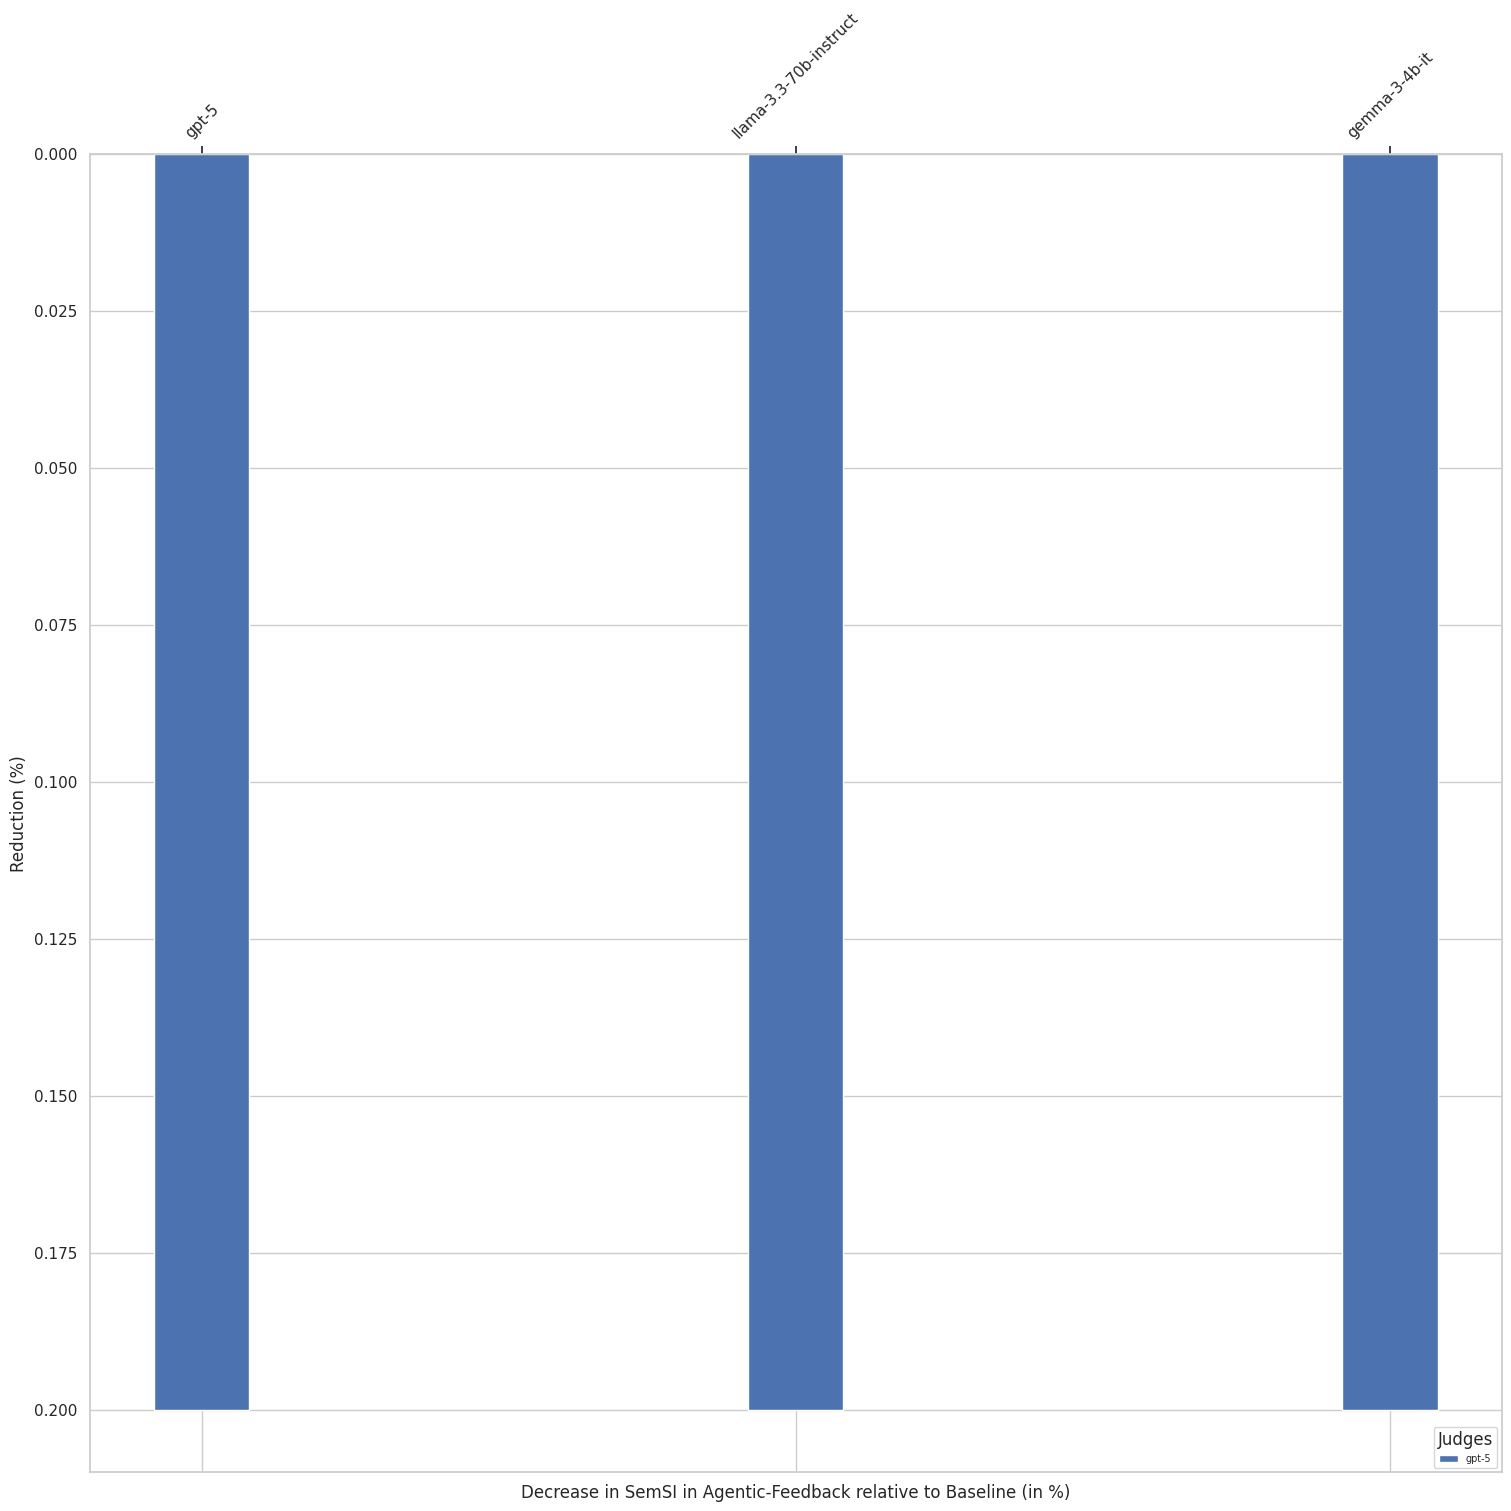

/tmp/ipykernel_5069/1162175626.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='left')


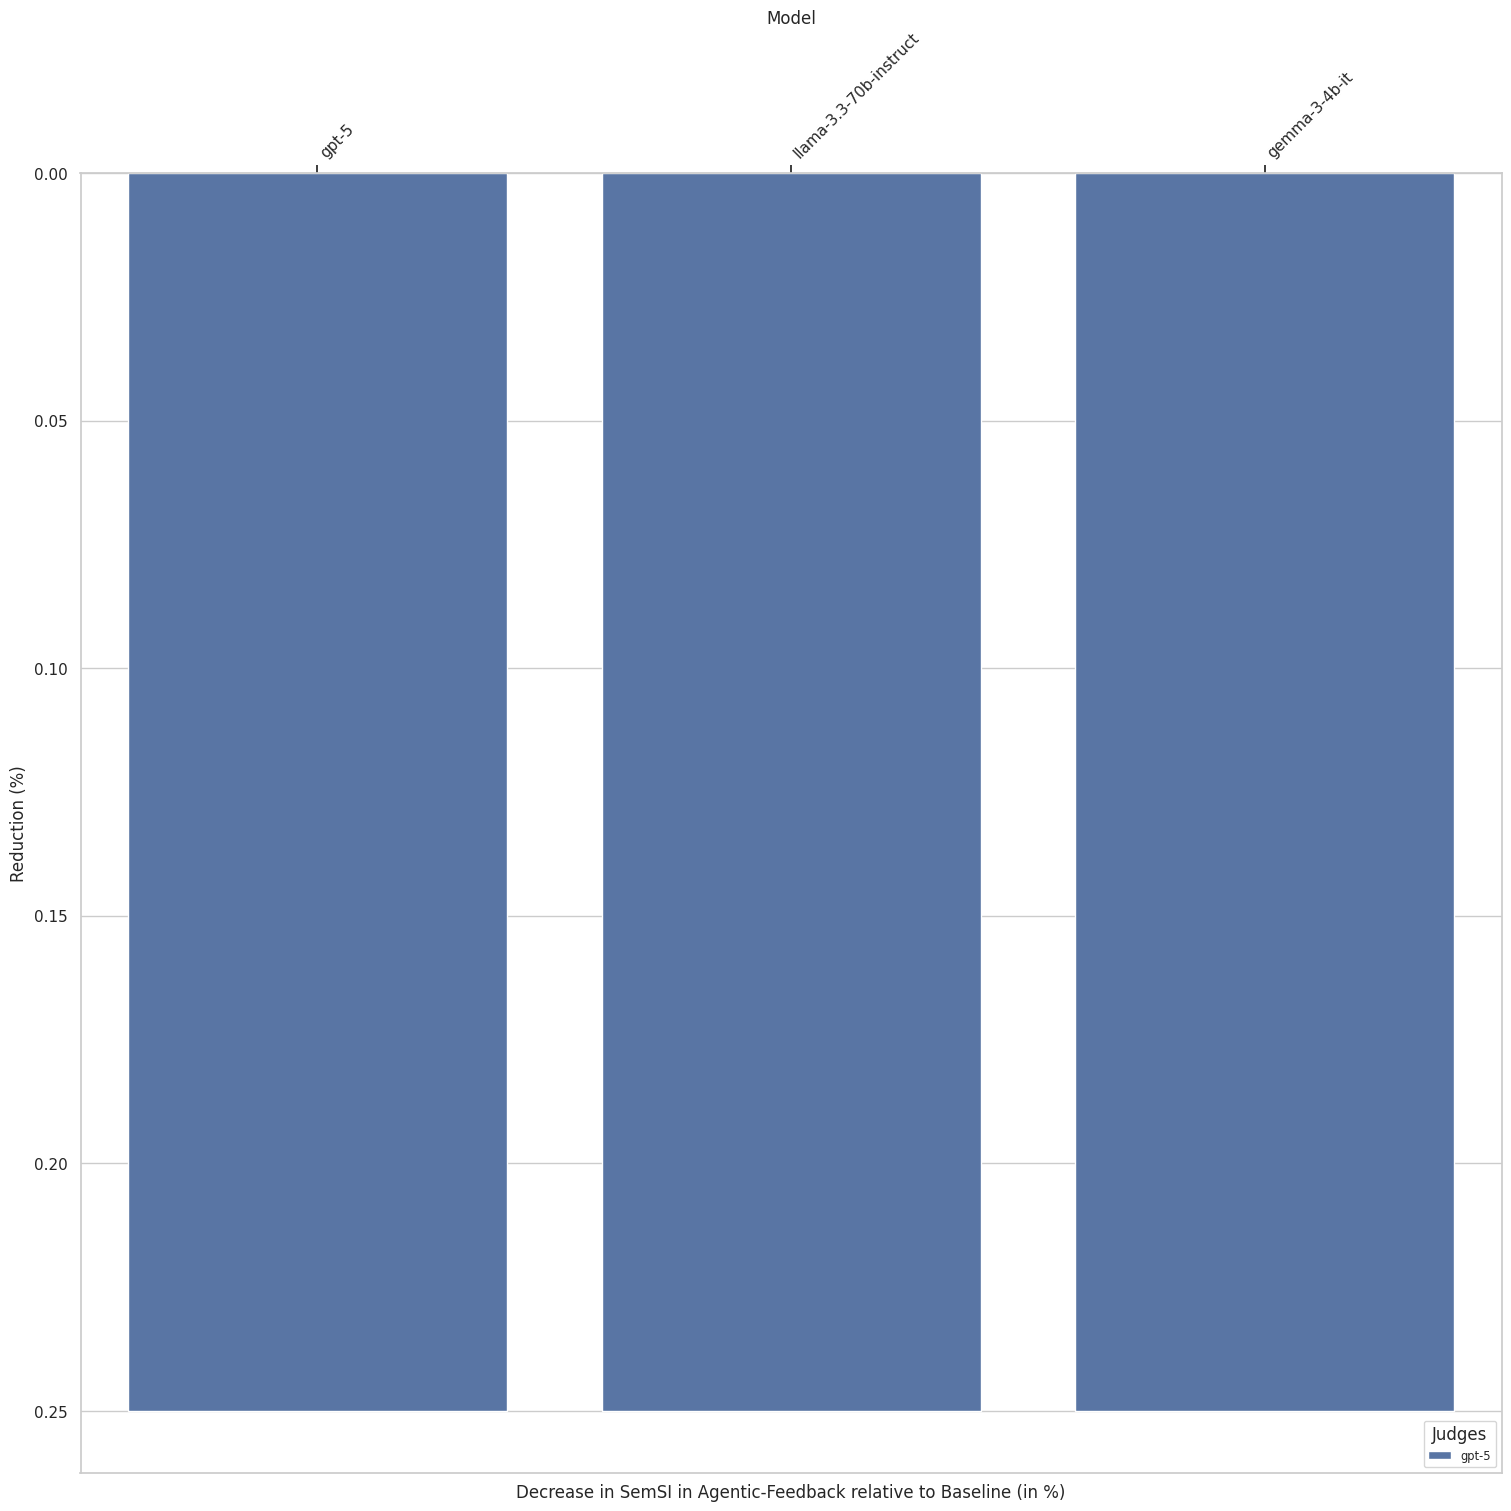

In [ ]:
show_reduction_bar_chart(utility=False)
fig = show_reduction_bar_chart_seaborn(utility=False)
fig.savefig('figures/semsi_reduction.pdf')

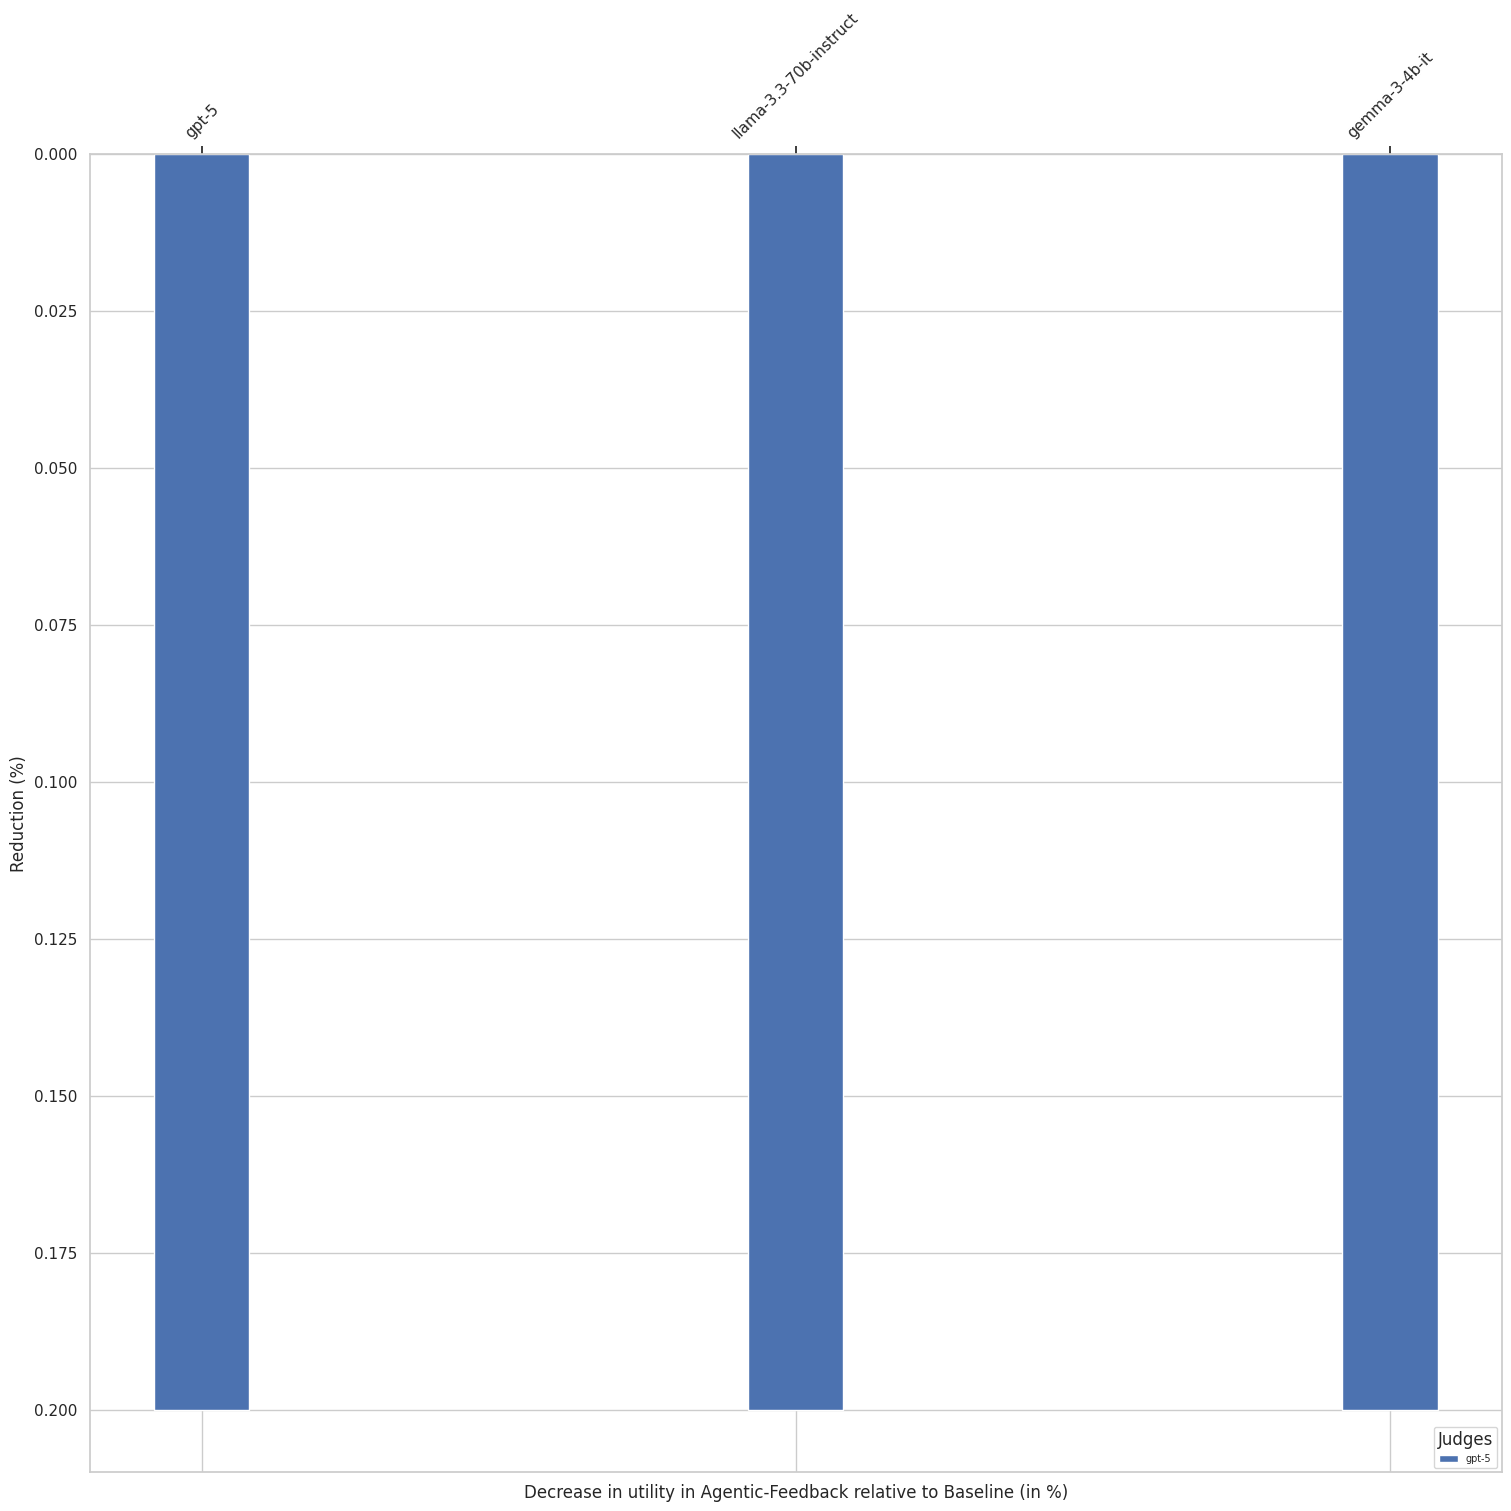

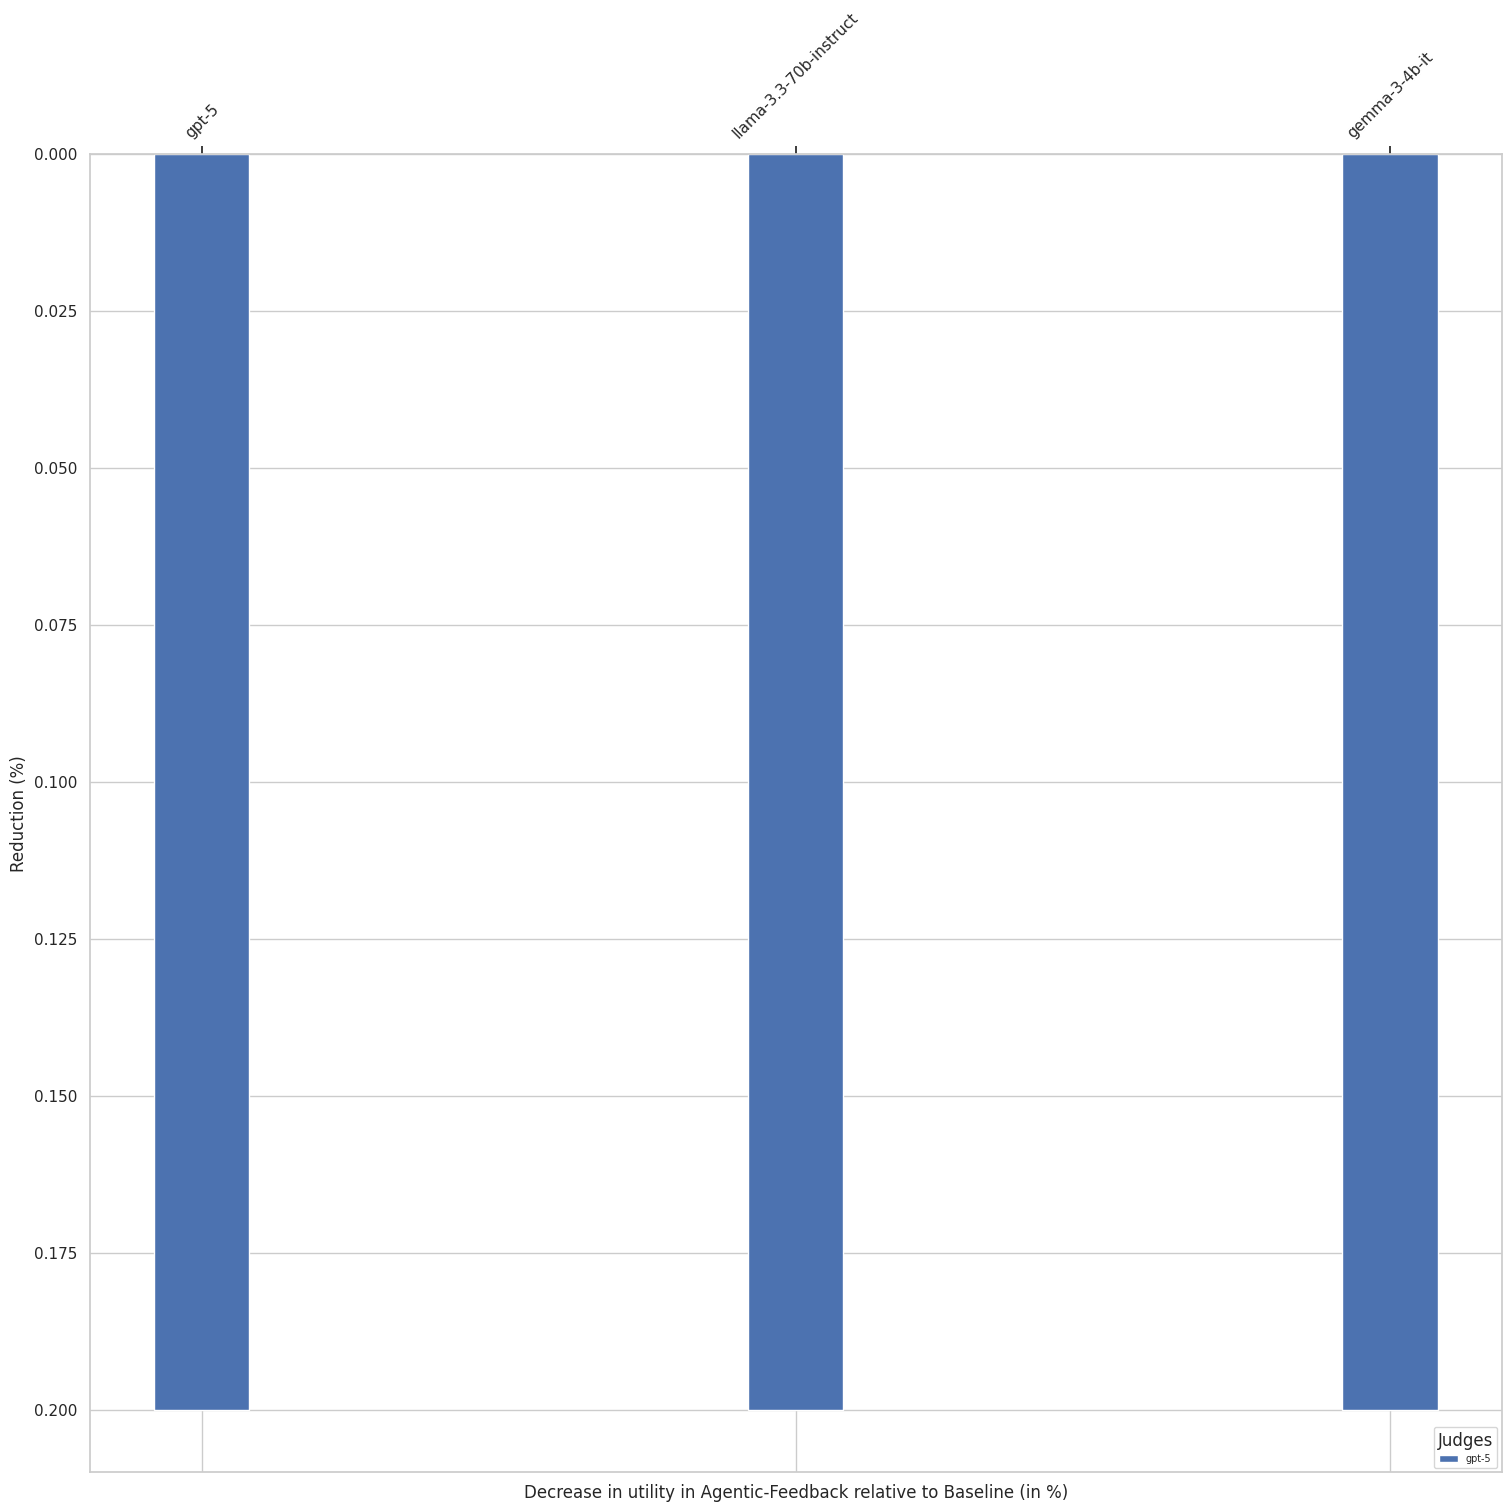

In [ ]:
show_reduction_bar_chart(utility=True)

# Statistical Justification

In [ ]:
df = general_df.copy()
df = df[(df['Method'] == 'Baseline') | (df['Method'] == 'Feedback')]
df = df[~df['Judge'].str.startswith('deepseek')]
df = df.drop(columns=['Toxicity', 'Coverage', 'Utility']).sort_values(by="Model")
print(df)

pivot = df.pivot_table(index=['Judge','Model'],
                       columns='Method',
                       values='Occurrence',
                       aggfunc='mean').reset_index()

# if column names are multiindex after pivot:
pivot.columns = [c if not isinstance(c, tuple) else c[1] for c in pivot.columns]

# ensure columns 'Baseline' and 'Feedback' exist
pivot = pivot.dropna(subset=['Baseline', 'Feedback'])

pivot = pivot[pivot['Baseline'] > 0].copy()

pivot['pct_decrease'] = (pivot['Baseline'] - pivot['Feedback']) / pivot['Baseline'] * 100

wide = pivot.pivot(index='Model', columns='Judge', values='pct_decrease')

wide_complete = wide.dropna(how='any')
print(wide_complete)

# ICC with pingouin
# pip install pingouin

# pingouin expects long-form: columns targets (items), raters, ratings
long = wide_complete.reset_index().melt(id_vars='Model', var_name='Judge', value_name='pct_decrease')

icc_all = pg.intraclass_corr(data=long, targets='Model', raters='Judge', ratings='pct_decrease')
print(icc_all)   # inspect rows: ICC1, ICC2, ICC3 etc.

# typically report ICC2 (two-way random, absolute agreement) or ICC3 (two-way mixed)
print(icc_all[['Type','ICC','F','df1','df2','pval','CI95%']])

# Pairwise Spearman correlation heatmap
corr = wide_complete.corr(method='spearman')
print(corr)

# Kendall's W
from scipy.stats import chi2

def kendalls_w(wide_df):
    ranks = wide_df.rank(axis=0, method='average')
    R = ranks.sum(axis=1)             # sum of ranks per item
    n = wide_df.shape[0]              # number of items
    m = wide_df.shape[1]              # number of judges
    S = ((R - R.mean())**2).sum()
    W = (12 * S) / (m**2 * (n**3 - n))
    # significance via chi-square approx:
    chi2_stat = m * (n - 1) * W
    pval = 1 - chi2.cdf(chi2_stat, df=n-1)
    return W, chi2_stat, pval

W, chi2_stat, pval = kendalls_w(wide_complete)
print("Kendall's W = {:.4f}, chi2 = {:.3f}, p = {:.4g}".format(W, chi2_stat, pval))

    Judge                   Model    Method  Occurrence  AnswerLength
9   gpt-5           gemma-3-4b-it  Feedback   90.000000      1247.870
3   gpt-5                   gpt-5  Feedback   28.140704      1393.000
12  gpt-5  llama-3.3-70b-instruct  Feedback   19.000000       394.795


KeyError: ['Baseline']